# Mean RMSE Comparison

This notebook builds a bar chart comparing mean RMSE for four Ariel models:
- RandomForest
- CNN
- Winner of ADC 2023 FMPE
- ExoBiome


In [16]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("/Users/mariaplatek/projects/AXION/notebooks")
RMSE_DIR = PROJECT_ROOT / "rmse"

RANDOM_FOREST_METRICS_JSON = RMSE_DIR / "random_forest_metrics.json"
CNN_METRICS_JSON = RMSE_DIR / "cnn_metrics.json"
WINNER_METRICS_JSON = RMSE_DIR / "sota_metrics.json"
EXOBIOME_METRICS_JSON = RMSE_DIR / "exobiome_metrics.json"

print("Project root:", PROJECT_ROOT)
print("RMSE dir:", RMSE_DIR)

Project root: /Users/mariaplatek/projects/AXION/notebooks
RMSE dir: /Users/mariaplatek/projects/AXION/notebooks/rmse


In [17]:
def load_json_metric_file(path: Path, model_name: str) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Metrics file not found: {path}")

    payload = json.loads(path.read_text())
    rmse = payload.get("rmse")
    rmse_mean = payload.get("rmse_mean")
    if rmse is None or rmse_mean is None:
        raise ValueError(f"Metric file missing rmse/rmse_mean: {path}")

    return {
        "model": model_name,
        "source": str(path),
        "rmse": dict(rmse),
        "rmse_mean": float(rmse_mean),
    }


def collect_model_metrics() -> tuple[list[dict], list[dict]]:
    metric_files = [
        ("RandomForest", RANDOM_FOREST_METRICS_JSON),
        ("CNN", CNN_METRICS_JSON),
        ("Winner", WINNER_METRICS_JSON),
        ("ExoBiome", EXOBIOME_METRICS_JSON),
    ]

    found = []
    missing = []
    for model_name, path in metric_files:
        try:
            found.append(load_json_metric_file(path, model_name))
        except Exception as exc:
            missing.append({"model": model_name, "reason": str(exc)})
    return found, missing

In [18]:
found_metrics, missing_metrics = collect_model_metrics()

summary_df = pd.DataFrame(
    [
        {
            "model": item["model"],
            "rmse_mean": item["rmse_mean"],
            "source": item["source"],
        }
        for item in found_metrics
    ]
).sort_values("rmse_mean", ignore_index=True)

display(summary_df)

if missing_metrics:
    missing_df = pd.DataFrame(missing_metrics)
    print("Missing model artifacts:")
    display(missing_df)

per_target_df = pd.DataFrame({item["model"]: item["rmse"] for item in found_metrics}).T
per_target_df.index.name = "model"
display(per_target_df)

,model,rmse_mean,source
0,ExoBiome,0.298693,/Users/mariaplatek/projects/AXION/notebooks/rm...
1,Winner,0.552288,/Users/mariaplatek/projects/AXION/notebooks/rm...
2,CNN,0.650037,/Users/mariaplatek/projects/AXION/notebooks/rm...
3,RandomForest,0.757240,/Users/mariaplatek/projects/AXION/notebooks/rm...


,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
model,,,,,
RandomForest,0.965600,0.668500,0.676900,0.614900,0.860300
CNN,0.809199,0.534054,0.609044,0.493321,0.804569
Winner,0.655048,0.454718,0.564497,0.454368,0.632811
ExoBiome,0.405183,0.228986,0.230328,0.236172,0.392794


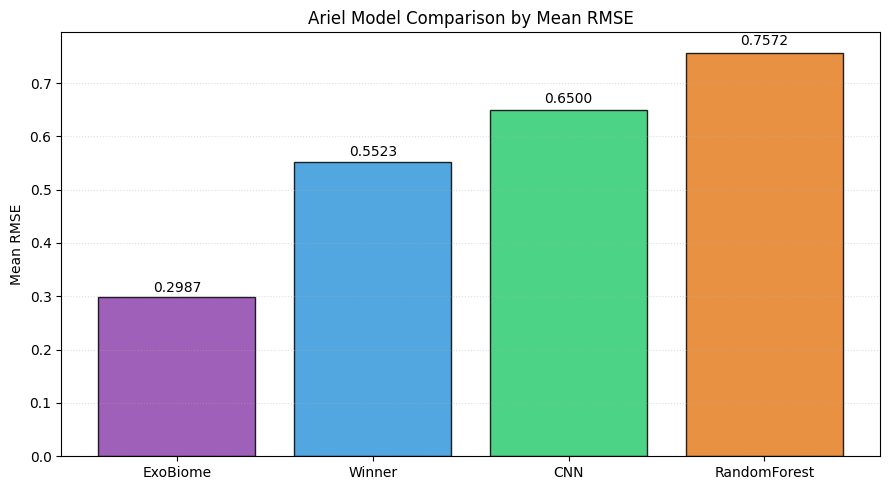

In [19]:
if summary_df.empty:
    raise RuntimeError("No model metrics were found. See the missing-model table above.")

plt.figure(figsize=(9, 5))
colors = ["#8e44ad", "#3498db", "#2ecc71", "#e67e22"]
bars = plt.bar(summary_df["model"], summary_df["rmse_mean"], color=colors[: len(summary_df)], edgecolor="black", alpha=0.85)
plt.ylabel("Mean RMSE")
plt.title("Ariel Model Comparison by Mean RMSE")
plt.grid(axis="y", linestyle=":", alpha=0.4)

for bar, value in zip(bars, summary_df["rmse_mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value * 1.01, f"{value:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Metric Sources

This notebook now reads all model RMSE metrics from `rmse/`:
- `RandomForest` from `rmse/random_forest_metrics.json`
- `CNN` from `rmse/cnn_metrics.json`
- `Winner of ADC 2023` from `rmse/sota_metrics.json`
- `ExoBiome` from `rmse/exobiome_metrics.json`

The values currently loaded from those files are:
- `RandomForest` mean RMSE: `0.75724`
- `CNN` mean RMSE: `0.65003745144915`
- `Winner of ADC` mean RMSE: `0.5522884130477905`
- `ExoBiome` mean RMSE: `0.29869264364242554`

This keeps the comparison notebook self-contained and makes the metric files easy to commit to GitHub.